# Onshore wind NPV simulation

Run the onshore wind electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_SAMPLE_SIZE,
    simulate_electricity_technology_npv,
)


In [2]:
TECHNOLOGY = 'wind_onshore'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED

rng = np.random.default_rng(RANDOM_SEED)
simulation = simulate_electricity_technology_npv(
    technology=TECHNOLOGY,
    size=SAMPLE_SIZE,
    rng=rng,
)
results = pd.DataFrame(simulation)

results.head()


,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,wind_onshore,1000000.0,2500.0,400.0,400000.0,1764.373629,38.535841,7.006475,0.0,...,94070000.0,1.541434e+07,7.006475e+06,0.0,0.0,7.164919e+07,5.908961e+07,25000000.0,2.363584,0.000002
1,1,wind_onshore,1000000.0,2500.0,400.0,400000.0,1563.327064,38.763591,6.985556,0.0,...,94070000.0,1.550544e+07,6.985556e+06,0.0,0.0,7.157901e+07,1.387591e+08,25000000.0,5.550362,0.000006
2,2,wind_onshore,1000000.0,2500.0,400.0,400000.0,1815.158752,33.157883,8.115047,0.0,...,94070000.0,1.326315e+07,8.115047e+06,0.0,0.0,7.269180e+07,4.990520e+07,25000000.0,1.996208,0.000002
3,3,wind_onshore,1000000.0,2500.0,400.0,400000.0,1718.420817,30.668389,7.338033,0.0,...,94070000.0,1.226736e+07,7.338033e+06,0.0,0.0,7.446461e+07,1.075247e+08,25000000.0,4.300989,0.000004
4,4,wind_onshore,1000000.0,2500.0,400.0,400000.0,1356.506409,35.272286,7.771694,0.0,...,94070000.0,1.410891e+07,7.771694e+06,0.0,0.0,7.218939e+07,2.280030e+08,25000000.0,9.120122,0.000009


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh
count,100000.000000,100000.000000
mean,145.628598,5.825144
std,71.109158,2.844366
min,-23.410354,-0.936414
5%,35.144436,1.405777
50%,145.150782,5.806031
95%,256.896494,10.275860
max,306.934224,12.277369


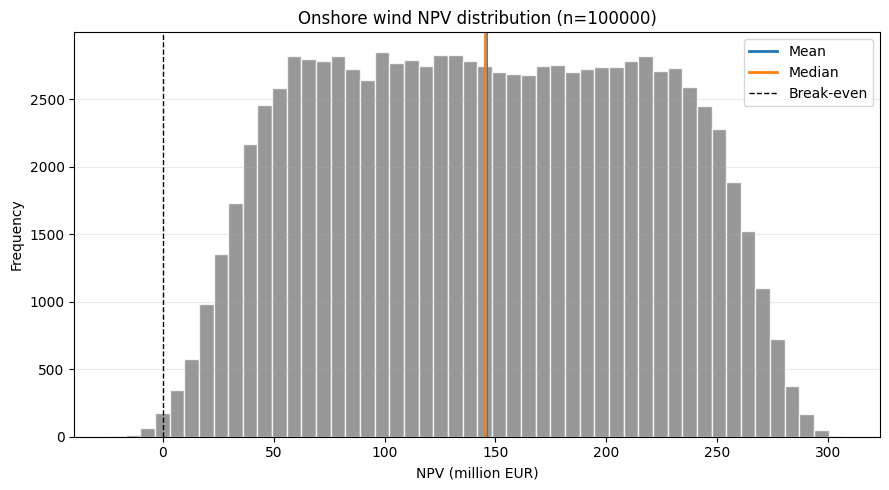

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Onshore wind NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## NPV per MWh histogram


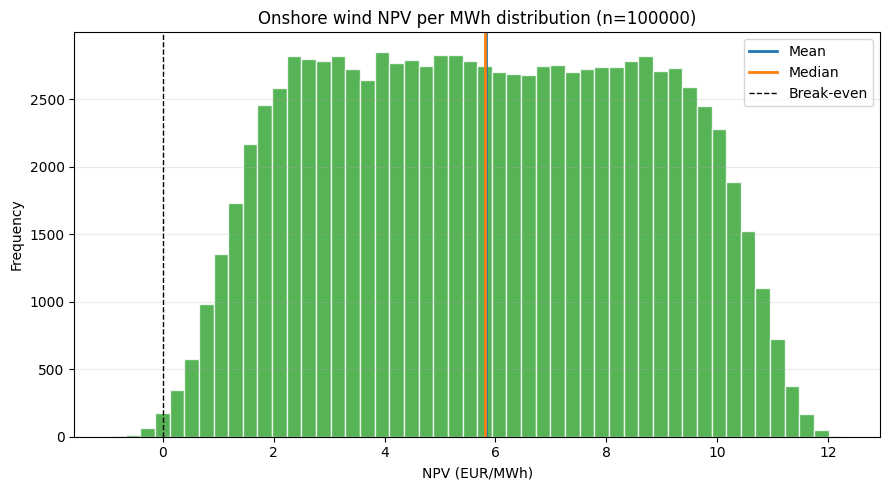

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Onshore wind NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur        13.224801
annual_variable_opex_eur      7.234421
annual_fuel_cost_eur          0.000000
annual_emissions_cost_eur     0.000000
annual_net_cash_flow_eur     73.610778
Name: Mean annual value, million EUR, dtype: float64